<a href="https://colab.research.google.com/github/srishtiii28/flight_delay_predictor/blob/main/flight_delay_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

Once your Drive is mounted, you can access your files. For example, if you have a CSV file named `my_dataset.csv` in the root of your Drive, you can load it into a pandas DataFrame like this:

In [3]:
import pandas as pd

file_path = '2018.csv'
df = pd.read_csv(file_path,nrows=7000)
df.to_csv("2018_final.csv")


# try:
#   df = pd.read_csv(file_path)
#   print(f"Successfully loaded data from {file_path}. Showing first 5 rows:")
#   display(df.head())
# except FileNotFoundError:
#   print(f"Error: File not found at {file_path}. Please check the path and make sure the file exists in your Google Drive.")
# except Exception as e:
#   print(f"An error occurred while loading the file: {e}")

In [4]:
# Fill NaN values in specific delay columns with 0
delay_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
df[delay_cols] = df[delay_cols].fillna(0)
print("Filled NaN values in delay columns with 0.")

# Fill NaN values in CANCELLATION_CODE with 'N/A'
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('N/A')
print("Filled NaN values in 'CANCELLATION_CODE' with 'N/A'.")

# Display missing values again to see the effect of these changes
print('\nMissing values per column after filling some NaNs:')
display(df.isnull().sum())

Filled NaN values in delay columns with 0.
Filled NaN values in 'CANCELLATION_CODE' with 'N/A'.

Missing values per column after filling some NaNs:


FL_DATE                   0
OP_CARRIER                0
OP_CARRIER_FL_NUM         0
ORIGIN                    0
DEST                      0
CRS_DEP_TIME              0
DEP_TIME                131
DEP_DELAY               147
TAXI_OUT                139
WHEELS_OFF              139
WHEELS_ON               144
TAXI_IN                 144
CRS_ARR_TIME              0
ARR_TIME                144
ARR_DELAY               161
CANCELLED                 0
CANCELLATION_CODE         0
DIVERTED                  0
CRS_ELAPSED_TIME          0
ACTUAL_ELAPSED_TIME     155
AIR_TIME                155
DISTANCE                  0
CARRIER_DELAY             0
WEATHER_DELAY             0
NAS_DELAY                 0
SECURITY_DELAY            0
LATE_AIRCRAFT_DELAY       0
Unnamed: 27            7000
dtype: int64

In [5]:
# Drop the 'Unnamed: 27' column as it's entirely empty
df = df.drop(columns=['Unnamed: 27'])
print("Dropped 'Unnamed: 27' column.")

# Convert 'FL_DATE' to datetime objects
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
print("Converted 'FL_DATE' to datetime.")

# Display info again to confirm changes
print('\nDataFrame Info after initial cleaning:')
df.info()

Dropped 'Unnamed: 27' column.
Converted 'FL_DATE' to datetime.

DataFrame Info after initial cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   FL_DATE              7000 non-null   datetime64[us]
 1   OP_CARRIER           7000 non-null   str           
 2   OP_CARRIER_FL_NUM    7000 non-null   int64         
 3   ORIGIN               7000 non-null   str           
 4   DEST                 7000 non-null   str           
 5   CRS_DEP_TIME         7000 non-null   int64         
 6   DEP_TIME             6869 non-null   float64       
 7   DEP_DELAY            6853 non-null   float64       
 8   TAXI_OUT             6861 non-null   float64       
 9   WHEELS_OFF           6861 non-null   float64       
 10  WHEELS_ON            6856 non-null   float64       
 11  TAXI_IN              6856 non-null   float64       
 12

In [6]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   FL_DATE              7000 non-null   datetime64[us]
 1   OP_CARRIER           7000 non-null   str           
 2   OP_CARRIER_FL_NUM    7000 non-null   int64         
 3   ORIGIN               7000 non-null   str           
 4   DEST                 7000 non-null   str           
 5   CRS_DEP_TIME         7000 non-null   int64         
 6   DEP_TIME             6869 non-null   float64       
 7   DEP_DELAY            6853 non-null   float64       
 8   TAXI_OUT             6861 non-null   float64       
 9   WHEELS_OFF           6861 non-null   float64       
 10  WHEELS_ON            6856 non-null   float64       
 11  TAXI_IN              6856 non-null   float64       
 12  CRS_ARR_TIME         7000 non-null   int64         
 13  ARR_TIME             6856 no

In [7]:
print('\nDataFrame Description (Numerical Columns):')
display(df.describe())


DataFrame Description (Numerical Columns):


,FL_DATE,OP_CARRIER_FL_NUM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,7000,7000.000000,7000.000000,6869.000000,6853.000000,6861.000000,6861.000000,6856.000000,6856.000000,7000.000000,...,7000.000000,7000.000000,6845.000000,6845.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,2018-01-01 00:00:00,2204.258000,1366.577143,1387.055175,21.288049,17.772628,1403.983384,1470.805426,8.559947,1498.293857,...,0.002286,150.933857,146.601315,120.263842,861.623429,7.223857,1.192286,2.843000,0.016571,9.915143
min,2018-01-01 00:00:00,1.000000,25.000000,1.000000,-30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,23.000000,28.000000,16.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-01-01 00:00:00,614.000000,945.000000,952.000000,-5.000000,12.000000,1007.000000,1059.000000,5.000000,1115.000000,...,0.000000,91.000000,86.000000,60.000000,352.750000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-01-01 00:00:00,1736.500000,1347.000000,1407.000000,0.000000,15.000000,1419.000000,1520.000000,7.000000,1524.000000,...,0.000000,134.000000,129.000000,102.000000,701.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018-01-01 00:00:00,3638.000000,1755.000000,1816.000000,25.000000,21.000000,1830.000000,1924.250000,10.000000,1928.250000,...,0.000000,181.250000,181.000000,153.000000,1090.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2018-01-01 00:00:00,6205.000000,2359.000000,2400.000000,762.000000,112.000000,2400.000000,2400.000000,92.000000,2359.000000,...,1.000000,690.000000,668.000000,637.000000,4983.000000,655.000000,397.000000,780.000000,26.000000,583.000000
std,NaN,1731.850372,494.525945,512.252509,53.381380,9.432909,515.939966,559.011225,6.943844,531.497176,...,0.047758,81.840676,80.744301,79.456575,666.103289,30.252385,13.602974,14.927182,0.583391,33.145097


In [8]:
df_filtered = df

In [9]:
# Drop rows with remaining missing values in key columns for delay prediction
df_filtered.dropna(subset=['DEP_DELAY', 'ARR_DELAY', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME'], inplace=True)

print(f"Flights after dropping rows with remaining NaNs: {len(df_filtered)}")

# Display missing values again to confirm
print('\nMissing values per column after final NaN removal:')
display(df_filtered.isnull().sum())

Flights after dropping rows with remaining NaNs: 6825

Missing values per column after final NaN removal:


FL_DATE                0
OP_CARRIER             0
OP_CARRIER_FL_NUM      0
ORIGIN                 0
DEST                   0
CRS_DEP_TIME           0
DEP_TIME               0
DEP_DELAY              0
TAXI_OUT               0
WHEELS_OFF             0
WHEELS_ON              0
TAXI_IN                0
CRS_ARR_TIME           0
ARR_TIME               0
ARR_DELAY              0
CANCELLED              0
CANCELLATION_CODE      0
DIVERTED               0
CRS_ELAPSED_TIME       0
ACTUAL_ELAPSED_TIME    0
AIR_TIME               0
DISTANCE               0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

### Handling Cancelled and Diverted Flights

For a flight delay predictor, we typically want to predict the delay for flights that actually operate and arrive. Therefore, we'll remove all rows where the flight was cancelled or diverted.

In [10]:
# Before dropping, let's see how many cancelled/diverted flights we have
print(f"Total flights: {len(df)}")
print(f"Cancelled flights: {df['CANCELLED'].sum()}")
print(f"Diverted flights: {df['DIVERTED'].sum()}")

# Filter out cancelled and diverted flights
df_filtered = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

print(f"Flights after removing cancelled/diverted: {len(df_filtered)}")

# Drop the 'CANCELLED' and 'DIVERTED' columns as they are no longer needed in this filtered dataset
df_filtered = df_filtered.drop(columns=['CANCELLED', 'DIVERTED'])
print("Dropped 'CANCELLED' and 'DIVERTED' columns from the filtered DataFrame.")

# Display missing values again for the filtered DataFrame to reassess
print('\nMissing values per column after filtering out cancelled/diverted flights:')
display(df_filtered.isnull().sum())

Total flights: 6825
Cancelled flights: 0.0
Diverted flights: 0.0
Flights after removing cancelled/diverted: 6825
Dropped 'CANCELLED' and 'DIVERTED' columns from the filtered DataFrame.

Missing values per column after filtering out cancelled/diverted flights:


FL_DATE                0
OP_CARRIER             0
OP_CARRIER_FL_NUM      0
ORIGIN                 0
DEST                   0
CRS_DEP_TIME           0
DEP_TIME               0
DEP_DELAY              0
TAXI_OUT               0
WHEELS_OFF             0
WHEELS_ON              0
TAXI_IN                0
CRS_ARR_TIME           0
ARR_TIME               0
ARR_DELAY              0
CANCELLATION_CODE      0
CRS_ELAPSED_TIME       0
ACTUAL_ELAPSED_TIME    0
AIR_TIME               0
DISTANCE               0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

In [11]:
print('\nMissing values per column:')
display(df.isnull().sum())


Missing values per column:


FL_DATE                0
OP_CARRIER             0
OP_CARRIER_FL_NUM      0
ORIGIN                 0
DEST                   0
CRS_DEP_TIME           0
DEP_TIME               0
DEP_DELAY              0
TAXI_OUT               0
WHEELS_OFF             0
WHEELS_ON              0
TAXI_IN                0
CRS_ARR_TIME           0
ARR_TIME               0
ARR_DELAY              0
CANCELLED              0
CANCELLATION_CODE      0
DIVERTED               0
CRS_ELAPSED_TIME       0
ACTUAL_ELAPSED_TIME    0
AIR_TIME               0
DISTANCE               0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

In [12]:
print('Missing values per column in df_filtered:')
display(df_filtered.isnull().sum())

Missing values per column in df_filtered:


FL_DATE                0
OP_CARRIER             0
OP_CARRIER_FL_NUM      0
ORIGIN                 0
DEST                   0
CRS_DEP_TIME           0
DEP_TIME               0
DEP_DELAY              0
TAXI_OUT               0
WHEELS_OFF             0
WHEELS_ON              0
TAXI_IN                0
CRS_ARR_TIME           0
ARR_TIME               0
ARR_DELAY              0
CANCELLATION_CODE      0
CRS_ELAPSED_TIME       0
ACTUAL_ELAPSED_TIME    0
AIR_TIME               0
DISTANCE               0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

## train-test-split

In [13]:
df["delay"] = (df["ARR_DELAY"] > 15).astype(int)

In [14]:
features = [
    "OP_CARRIER",
    "ORIGIN",
    "DEST",
    "CRS_DEP_TIME",
    "DISTANCE",
    "CRS_ELAPSED_TIME"
]

X = df[features]
y = df["delay"]

In [15]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["OP_CARRIER", "ORIGIN", "DEST"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight={0:1, 1:3},
    random_state=42
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
y_pred = model.predict(X_test)
# print("precision score:",precision_score(y_test,y_pred))

Accuracy: 0.7025641025641025


In [17]:
joblib.dump(model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [27]:
y_prob = model.predict_proba(X_test)[:,1]

# try different thresholds
y_pred_03 = (y_prob > 0.3).astype(int)
y_pred_025 = (y_prob > 0.25).astype(int)

In [29]:
from sklearn.metrics import confusion_matrix,classification_report
y_pred = model.predict(X_test)
print(classification_report(y_pred_03,y_pred_025))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89       512
           1       0.89      1.00      0.94       853

    accuracy                           0.92      1365
   macro avg       0.95      0.90      0.91      1365
weighted avg       0.93      0.92      0.92      1365



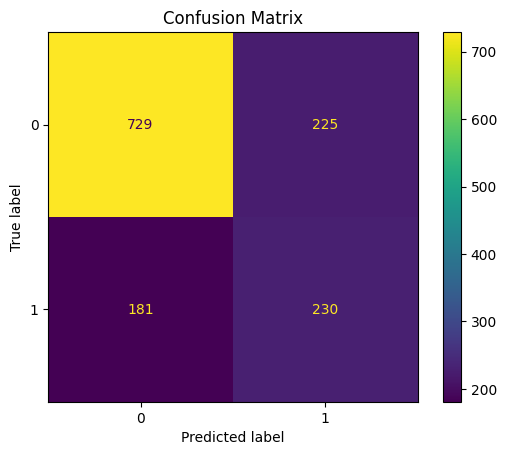

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

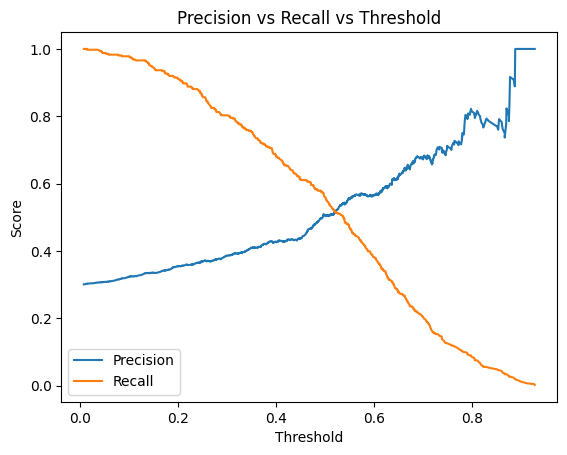

In [31]:
from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()

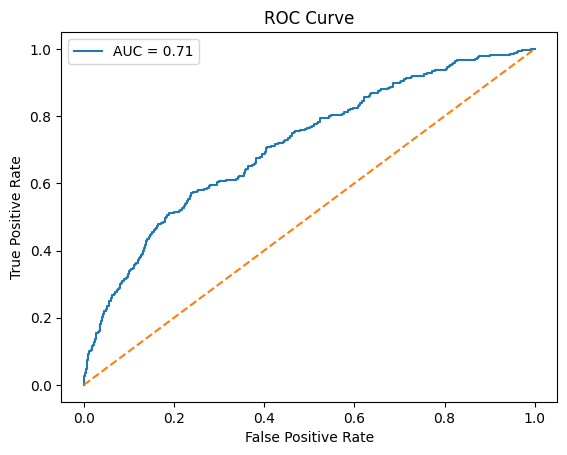

In [32]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

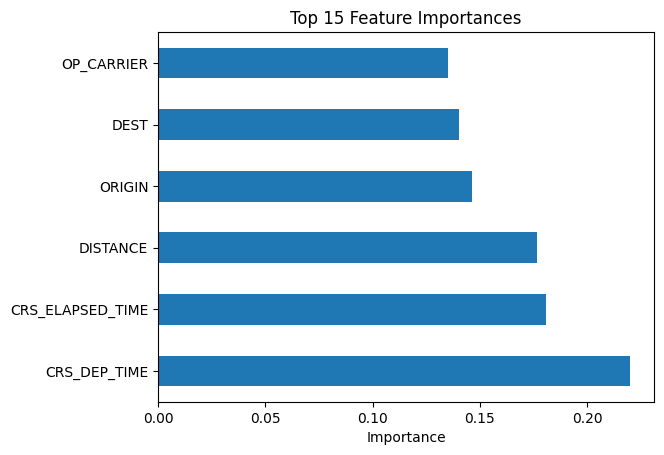

In [33]:
import pandas as pd

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure()
feat_imp.head(15).plot(kind='barh')

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

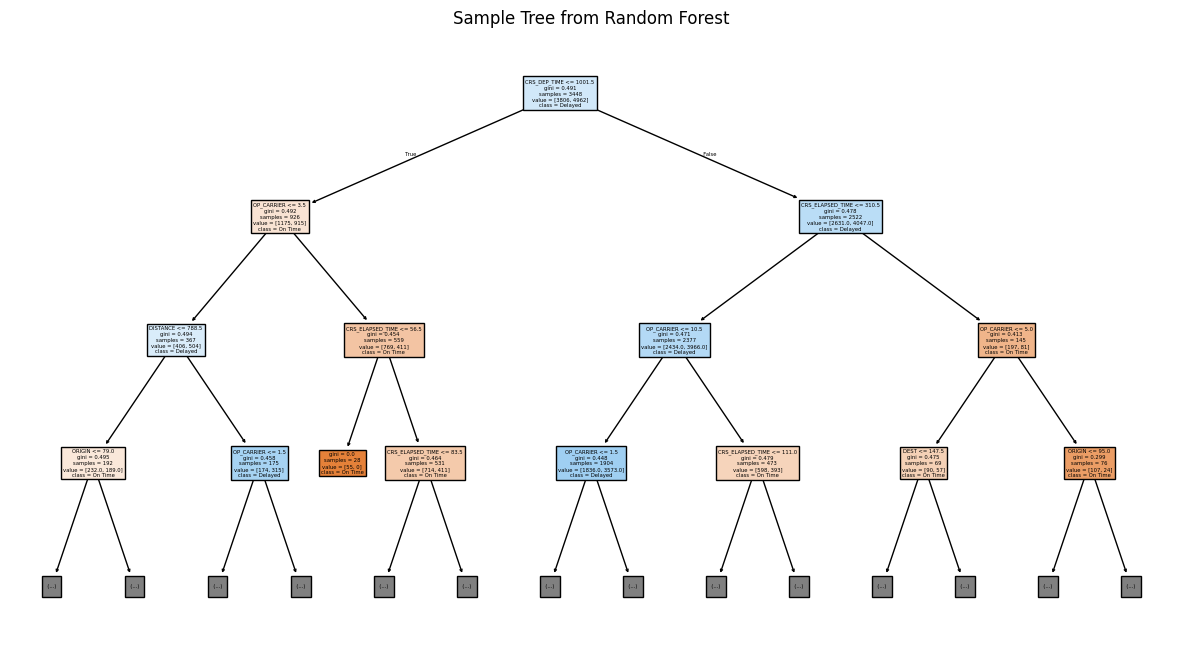

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))
plot_tree(model.estimators_[0],
          feature_names=X.columns,
          class_names=["On Time", "Delayed"],
          filled=True,
          max_depth=3)

plt.title("Sample Tree from Random Forest")
plt.show()

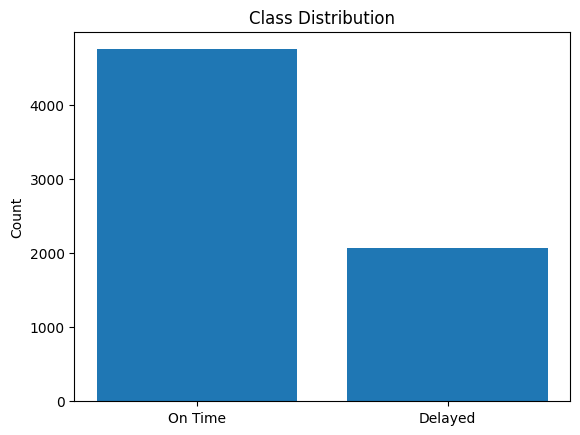

In [35]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)

plt.figure()
plt.bar(unique, counts)

plt.xticks([0, 1], ["On Time", "Delayed"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

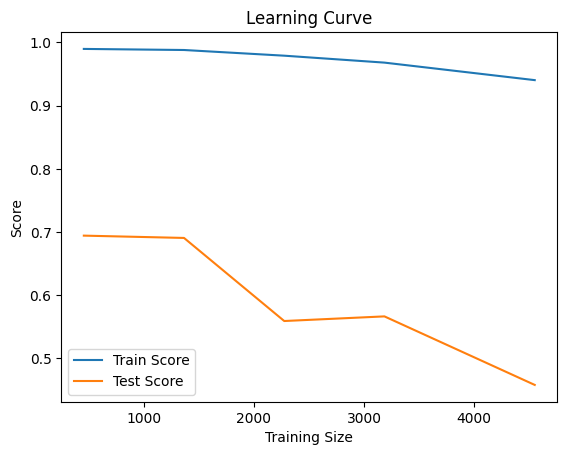

In [36]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=3, n_jobs=-1,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0]
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Test Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

### Recall vs Threshold Plot

This graph illustrates the relationship between different threshold values and the recall metric for predicting flight delays. Recall measures the model's ability to correctly identify delayed flights (true positives divided by actual positives). As the threshold increases, the model becomes more conservative in predicting delays, which typically decreases recall but may increase precision. This visualization helps in understanding the trade-off between sensitivity (recall) and specificity when adjusting the decision threshold for the flight delay prediction model.

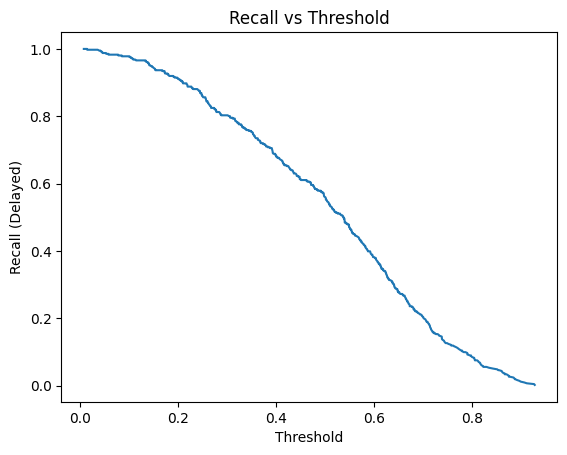

In [37]:
plt.figure()
plt.plot(thresholds, recall[:-1])

plt.xlabel("Threshold")
plt.ylabel("Recall (Delayed)")
plt.title("Recall vs Threshold")

plt.show()

📊 Model Evaluation & System Analysis
1. 🔲 Confusion Matrix Analysis

Values:

True Negatives (On-time correctly predicted): 729
False Positives (On-time predicted as delayed): 225
False Negatives (Delayed missed): 181
True Positives (Delayed correctly predicted): 230
📌 Insights:
The model performs well for on-time flights (high TN).
However, it still misses a significant number of delays (181).

Delay detection recall ≈ 56%, meaning:

~44% of delayed flights are still not detected.

✅ Conclusion:

Model is moderately good, but still risky for real-world deployment where missing delays is costly.

📈 2. Precision vs Recall vs Threshold
📌 Observations:
As threshold increases:
Precision ↑
Recall ↓
At ~0.3–0.4 threshold:
Balanced trade-off between precision & recall
🔥 Key Insight:
Default threshold (0.5) is NOT optimal
Lower threshold improves delay detection significantly
✅ Conclusion:

Optimal threshold should be around 0.3–0.4 for this problem.

📉 3. ROC Curve (AUC = 0.71)
📌 Interpretation:
AUC = 0.71 → Model is decent but not strong
Better than random (0.5), but far from excellent (0.85+)
✅ Conclusion:

Model has reasonable discrimination ability, but needs improvement for high-stakes prediction.

🌳 4. Feature Importance Analysis
🔝 Top Features:
CRS_DEP_TIME (departure time)
CRS_ELAPSED_TIME
DISTANCE
ORIGIN
DEST
OP_CARRIER
📌 Insights:
Time-related features dominate → delays strongly depend on schedule timing
Distance & route also matter → operational complexity
Airline (carrier) has noticeable influence → real-world consistency
⚠️ Concern:
No weather / congestion / historical delay features
→ Model may be missing critical signals
✅ Conclusion:

Model is learning meaningful patterns, but feature set is incomplete

🌲 5. Random Forest Tree Visualization
📌 Observations:
Model splits primarily on:
Departure time
Carrier
Distance
Trees are:
Structured
Interpretable at shallow depth
🧠 Insight:

Random Forest is:

Learning hierarchical decision rules like:

“If late departure time + certain carrier → higher delay probability”
✅ Conclusion:

Model logic is interpretable and reasonable

📊 6. Class Distribution
On-time flights ≈ 4700+
Delayed flights ≈ 2000+
📌 Insight:
Dataset is imbalanced (~70:30)
Explains why model initially biased toward “on-time”
✅ Conclusion:

Use of class_weight was necessary and correct

📉 7. Learning Curve Analysis
📌 Observations:
Training score ≈ 0.95–0.99
Test score drops to ≈ 0.45–0.70
🚨 Critical Insight:

Clear Overfitting

Model memorizes training data
Struggles to generalize
✅ Conclusion:

This is your BIGGEST problem right now

📉 8. Recall vs Threshold
📌 Observations:
Recall is:
~1.0 at very low threshold
Drops sharply as threshold increases
🔥 Key Insight:
At threshold ~0.3:
Recall ≈ 0.65–0.7 (ideal range)
✅ Conclusion:

Lowering threshold is the easiest way to boost performance

🧠 FINAL SYSTEM DIAGNOSIS
✅ Strengths:
Good handling of class imbalance
Interpretable feature importance
Decent ROC performance (0.71)
Significant improvement in delay detection
❌ Weaknesses:
Overfitting (major issue)
Missing important features (weather, history)
Recall still not high enough for real-world use
Default threshold hurting performance